In [21]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [22]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [23]:
compact = True

In [24]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(os.path.join(data_dir, f"combined_{timestamp}.parquet"))

    # Move files already in trash to trash within trash
    trash = os.path.join(data_dir, "trash")
    trash_in_trash = os.path.join(trash, f"trash_{timestamp}")
    os.makedirs(trash_in_trash, exist_ok=True)
    for f in os.listdir(trash):
        if f.endswith(".parquet") or f.endswith(".csv"):
            os.rename(os.path.join(trash, f), os.path.join(trash_in_trash, f))
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading 2024-09-07_12-42-50.parquet
Reading 2024-09-07_13-31-08.parquet
Reading 2024-09-07_14-18-25.parquet
Reading 2024-09-07_12-05-01.parquet
Reading 2024-09-07_14-14-04.parquet
Reading 2024-09-07_13-28-18.parquet
Reading 2024-09-07_14-03-36.parquet
Reading 2024-09-07_14-10-57.parquet
Reading 2024-09-07_14-04-26.parquet
Reading combined_20240906175220.parquet
Reading 2024-09-07_11-51-48.parquet
Reading 2024-09-07_14-30-33.parquet
Reading 2024-09-07_12-10-48.parquet
Reading 2024-09-07_14-17-03.parquet
Reading 2024-09-07_13-49-39.parquet
Reading 2024-09-07_13-27-04.parquet
Reading 2024-09-07_14-42-21.parquet
Reading 2024-09-07_12-02-59.parquet
Reading 2024-09-07_13-27-50.parquet
Reading 2024-09-07_13-51-59.parquet
Reading 2024-09-07_12-36-36.parquet
Reading 2024-09-07_12-00-30.parquet
Reading 2024-09-07_14-30-10.parquet
Reading 2024-09-07_13-43-57.parquet
Reading 2024-09-07_13-35-02.parquet
Reading 2024-09-07_14-19-19.parquet
Reading 2024-09-07_15-15-25.parquet
Reading 2024-09-07_11-31

,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
02ac3885-8adc-4514-bc2e-a93dd59eb5e7,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,2,0.5317,0.015951,0,"[10, 1, 0, 0, 0]",1268.0,NaN
8165e023-0a23-4615-9b6e-7bedbb4e1121,02ac3885-8adc-4514-bc2e-a93dd59eb5e7,[],"[96, 90]",0,"[4, 10]","[4, 10]","[True, True]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,6,0.5317,0.037219,0,"[10, 1, 0, 0, 0]",1268.0,NaN
7be841ac-ab2a-44b1-ad65-776b76ad928e,8165e023-0a23-4615-9b6e-7bedbb4e1121,"[27, 0, 32]","[90, 90]",0,"[0, 0]","[10, 10]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,14,0.6365,0.063650,1,"[1, 10, 6, 0, 0]",1268.0,NaN
d0bb01b6-61aa-428e-a049-c611dae09867,7be841ac-ab2a-44b1-ad65-776b76ad928e,"[27, 0, 32, 2]","[76, 76]",0,"[0, 0]","[24, 24]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,5,0.5728,0.137472,1,"[1, 10, 6, 2, 0]",1268.0,NaN
5ea29610-76e2-47d0-b940-658947229d75,d0bb01b6-61aa-428e-a049-c611dae09867,"[27, 0, 32, 2, 14]","[71, 71]",0,"[0, 0]","[29, 29]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,45,0.9493,0.275297,3,"[1, 10, 6, 0, 0]",1268.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1be8baa5-8428-45c7-a205-e4d975c1df2b,fc48cddc-d45e-4286-a0f1-c8add3761d9e,"[21, 7, 24, 19, 27]","[153, 25]",0,"[0, 0]","[11, 11]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.2808,0.030888,0,"[11, 10, 8, 7, 6]",498.0,NaN
70f78529-a5e9-4b6c-95af-58a3f96a4c83,None,[],"[149, 43]",0,"[4, 4]","[4, 4]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],raise,4,0.6382,0.025528,0,"[11, 10, 0, 0, 0]",543.0,NaN
a7b23046-4cc8-4656-85e9-2cf0d6c1a1e7,70f78529-a5e9-4b6c-95af-58a3f96a4c83,"[13, 47, 31]","[145, 39]",0,"[0, 0]","[8, 8]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],check,0,0.4720,0.037760,0,"[11, 10, 8, 5, 0]",543.0,NaN


In [25]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [26]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [27]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,game_id,action,amount,excess_rank,p,relative_ev,stage,player_name,opponent_name,n_players
5898009760,0,0,0,0,0,0,0,0,0,0,...,2a872606-fc0b-45a5-93dd-94d6fcde0c74,call,2,0,0.5762,0.017286,preflop,Arin,,2
6118269520,0,0,0,0,0,0,0,0,0,0,...,fcef1e8b-6426-4c96-ae04-8e692c202f78,check,0,0,0.3057,0.012228,preflop,Arin,,2
5900902016,0,0,0,0,0,0,0,0,0,0,...,634fab97-c2c3-4b62-bba2-47d7b1e64054,check,0,0,0.5584,0.022336,preflop,Tord,,2
6094468192,0,0,0,0,0,0,0,0,0,0,...,c356d6b9-e920-4607-972e-ca8e8961ba79,fold,0,0,0.4566,0.013698,preflop,Arin,,2
b2e89e2d-12c8-4563-a2c0-2e482e672ec6,0,0,0,0,0,0,0,0,0,0,...,316a4a8b-2146-4d31-b25e-cc1ac32c2b53,call,2,0,0.4511,0.013533,preflop,Tord,,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162171888,0,22,21,0,0,6,5,0,0,0,...,746f2d0b-8ca7-4b54-acc0-0adca5069092,call,10,1,0.8652,0.527772,turn,Arin,,2
4306213712,0,0,0,0,0,6,9,14,0,0,...,b3be6314-e9a7-4df3-9d13-0f0b9b2b73f2,call,4,1,0.8017,0.264561,river,Arin,,2
6162184512,0,22,21,0,0,6,5,10,0,0,...,746f2d0b-8ca7-4b54-acc0-0adca5069092,check,0,1,0.8571,0.565686,river,Arin,,2
6165562320,0,69,0,0,0,6,13,0,0,0,...,35204490-c39b-499c-a71d-454969c6ce12,check,0,2,0.7730,0.695700,turn,Arin,,2


In [28]:
df.dtypes

raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn          int64
opponent_check_river

## Training

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [30]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [31]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_flop,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,opponent_name,n_players
5898009760,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,Arin,,2
6118269520,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,check,0,preflop,Arin,,2
5900902016,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,check,0,preflop,Tord,,2
6094468192,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,fold,0,preflop,Arin,,2
b2e89e2d-12c8-4563-a2c0-2e482e672ec6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,Tord,,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162171888,0,22,21,0,0,6,5,0,0,0,...,1,1,0,0,call,10,turn,Arin,,2
4306213712,0,0,0,0,0,6,9,14,0,0,...,1,1,1,0,call,4,river,Arin,,2
6162184512,0,22,21,0,0,6,5,10,0,0,...,1,1,1,0,check,0,river,Arin,,2
6165562320,0,69,0,0,0,6,13,0,0,0,...,1,1,0,0,check,0,turn,Arin,,2


In [32]:
y

5898009760                              0.5762
6118269520                              0.3057
5900902016                              0.5584
6094468192                              0.4566
b2e89e2d-12c8-4563-a2c0-2e482e672ec6    0.4511
                                         ...  
6162171888                              0.8652
4306213712                              0.8017
6162184512                              0.8571
6165562320                              0.7730
6165583184                              0.9015
Name: p, Length: 5316, dtype: float64

In [33]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name", "opponent_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [34]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (4224, 36)
Test shape: (1092, 36)


In [35]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor', LinearRegression())])

In [36]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.1682431386146213
MAE: 0.1299584610714274
MAPE: 35.57%


,y_test,y_pred
5898009760,0.5762,0.540622
6094468192,0.4566,0.416826
6101329712,0.4846,0.485941
032dac0d-ac3f-4389-a829-98bacb284134,0.6241,0.542190
eceeeca9-b567-488a-8230-722717edcaf3,0.5839,0.640298
...,...,...
6152861920,0.1230,0.515462
6165563904,0.7229,0.866661
6165442032,0.7229,0.791312
6165562320,0.7730,0.816645


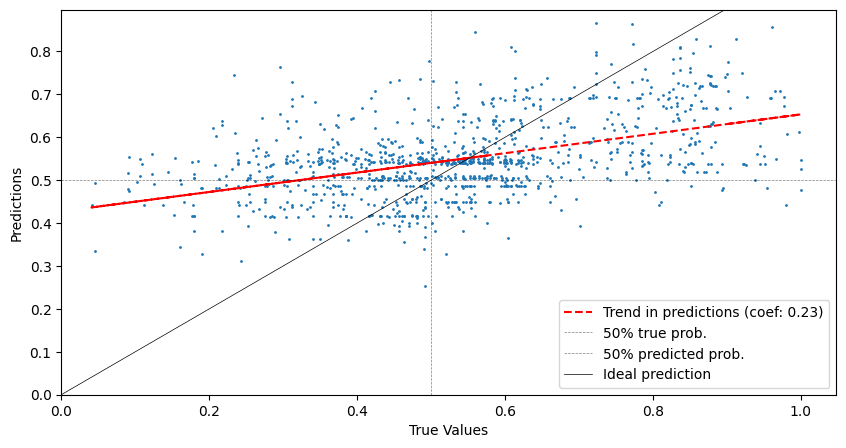

In [37]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()

### Examine feature importance

In [38]:
# Calculate feature importance
# Get the one-hot encoded feature names
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names, X.columns[len(categorical_cols):]])

coefs = model.named_steps["regressor"].coef_

# Sort by absolute value
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df

,feature,coef,abs_coef
13,call_preflop,1.488577e+11,1.488577e+11
33,opponent_check_preflop,-1.488577e+11,1.488577e+11
16,call_river,-9.382871e+09,9.382871e+09
20,check_turn,3.364563e+09,3.364563e+09
34,opponent_check_flop,2.715906e+09,2.715906e+09
14,call_flop,-2.715906e+09,2.715906e+09
35,opponent_check_turn,2.394602e+09,2.394602e+09
15,call_turn,-2.394602e+09,2.394602e+09
12,raise_showdown,1.323889e+09,1.323889e+09
32,opponent_call_showdown,-1.323889e+09,1.323889e+09


### Compare to XGBoost

In [39]:
from xgboost import XGBRegressor

# Create the full pipeline with XGBoost
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "regressor",
            XGBRegressor(
                n_estimators=100,
                objective="reg:squarederror",
                learning_rate=0.01,
                max_depth=3,
                reg_alpha=1,
                reg_lambda=1,
            ),
        ),
    ]
)

In [40]:
# Cross validate to find good hyperparameters
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'regressor__n_estimators': [100, 500],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
}

# Grid search over the XGBRegressor parameters
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'regressor__colsample_bytree': 0.6, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 7, 'regressor__n_estimators': 500, 'regressor__subsample': 0.6}
-0.025451680518478126


In [41]:
# Use the best model
model = grid_search.best_estimator_

In [42]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.6, device=None,
                              early_stopping_rounds=None,
                              e...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [43]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.1602254144624976
MAE: 0.12096597284979217
MAPE: 33.57%


,y_test,y_pred
5898009760,0.5762,0.518582
6094468192,0.4566,0.422793
6101329712,0.4846,0.520594
032dac0d-ac3f-4389-a829-98bacb284134,0.6241,0.531775
eceeeca9-b567-488a-8230-722717edcaf3,0.5839,0.569062
...,...,...
6152861920,0.1230,0.453740
6165563904,0.7229,0.679019
6165442032,0.7229,0.619597
6165562320,0.7730,0.638878


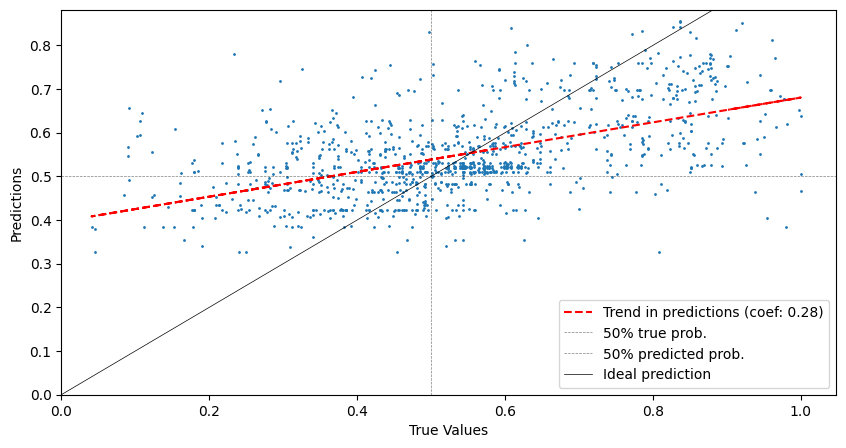

In [44]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()